In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh, inv, solve

# ==========================================
# 1. 核心功能函数库 (Function Library)
# ==========================================

def solve_modal_properties(M, K):
    """
    求解特征值问题 (K - w^2 M)phi = 0
    返回: 固有频率(Hz), 原始振型矩阵
    """
    # eigh 用于对称矩阵，更稳定
    evals, evecs = eigh(K, M)
    
    # 容错：处理计算误差产生的微小负数
    evals = np.where(evals < 0, 0, evals)
    omegas = np.sqrt(evals)
    freqs_hz = omegas / (2 * np.pi)
    
    return omegas, freqs_hz, evecs

def normalize_mode_shapes(M, modes, method='mass'):
    """
    归一化振型
    method='mass': 质量归一化 (phi.T * M * phi = I)
    method='max':  最大元素归一化 (让最大值为1)
    """
    normalized_modes = np.copy(modes)
    n_modes = modes.shape[1]
    
    for i in range(n_modes):
        u = modes[:, i]
        if method == 'mass':
            modal_mass = u.T @ M @ u
            scale = 1.0 / np.sqrt(modal_mass)
            normalized_modes[:, i] = u * scale
        elif method == 'max':
            # 找绝对值最大的元素，保留符号
            idx = np.argmax(np.abs(u))
            scale = 1.0 / u[idx]
            normalized_modes[:, i] = u * scale
        elif method == 'first':
            # 第一项为 1
            scale = 1.0 / u[0]
            normalized_modes[:, i] = u * scale
            
    return normalized_modes

def compute_frf_ij(M, C, K, omega_range, i_dof, j_dof):
    """
    计算第 i 个自由度的位移，由于第 j 个自由度的单位力激励
    H_ij(w) = X_i / F_j
    """
    n_dof = M.shape[0]
    n_freqs = len(omega_range)
    
    # 初始化复数数组
    response_complex = np.zeros(n_freqs, dtype=complex)
    
    # 定义力向量 F (只有第 j 个位置是 1)
    F_vec = np.zeros(n_dof)
    F_vec[j_dof] = 1.0  # Unit excitation
    
    for k, w in enumerate(omega_range):
        # 动刚度矩阵 D(w) = K - w^2 M + i w C
        D = K - (w**2)*M + 1j*w*C
        
        # 求解线性方程 D * X = F  => X = D_inv * F
        # 使用 solve 比求逆更准
        X_vec = solve(D, F_vec)
        
        # 取出第 i 个自由度的响应
        response_complex[k] = X_vec[i_dof]
        
    magnitude = np.abs(response_complex)
    phase = np.angle(response_complex, deg=True) # 角度制
    
    return magnitude, phase, response_complex

def get_peak_details(omegas, magnitude):
    """
    获取响应曲线中的最大峰值 (Resonance Peak)
    返回: 峰值频率, 峰值幅值, 峰值对应 Peak-to-Peak
    """
    idx_max = np.argmax(magnitude)
    peak_freq = omegas[idx_max]
    peak_amp = magnitude[idx_max]
    peak_to_peak = 2 * peak_amp  # 简谐振动 P-P = 2 * Amplitude
    
    return peak_freq, peak_amp, peak_to_peak

def plot_frf_response(freqs_hz, mag, phase, i_dof, j_dof):
    """
    画图: 幅频特性和相频特性
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # 1. Amplitude Plot
    ax1.plot(freqs_hz, mag, 'b-', linewidth=1.5)
    ax1.set_ylabel(f'Amplitude $|H_{{{i_dof}{j_dof}}}|$ (m/N)', fontsize=12)
    ax1.set_title(f'Frequency Response: Output DOF {i_dof} / Input DOF {j_dof}', fontsize=14)
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)
    # ax1.set_yscale('log') # 如果需要对数坐标取消注释
    
    # 标记最大值
    idx_max = np.argmax(mag)
    ax1.plot(freqs_hz[idx_max], mag[idx_max], 'ro')
    ax1.text(freqs_hz[idx_max], mag[idx_max], f' Peak: {mag[idx_max]:.2e}', verticalalignment='bottom')

    # 2. Phase Plot
    ax2.plot(freqs_hz, phase, 'r-', linewidth=1.5)
    ax2.set_ylabel('Phase (degrees)', fontsize=12)
    ax2.set_xlabel('Frequency (Hz)', fontsize=12)
    ax2.set_yticks(np.arange(-180, 181, 90)) # -180 到 180
    ax2.grid(True, which='both', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. 主封装函数 (One-Stop Shop)
# ==========================================

def analyze_mdof_system(M, C, K, i_dof, j_dof, f_start, f_end, f_steps=1000):
    """
    超级入口: 输入矩阵和位置，自动完成所有计算和画图
    注意: i_dof 和 j_dof 从 0 开始计数 (0 = x1, 1 = x2...)
    """
    print("="*50)
    print(f"🔩 MDOF System Analysis (Input: {j_dof} -> Output: {i_dof})")
    print("="*50)

    # 1. 模态分析
    omegas, freqs_hz, raw_modes = solve_modal_properties(M, K)
    
    # 2. 归一化
    modes_mass = normalize_mode_shapes(M, raw_modes, method='mass')
    modes_max  = normalize_mode_shapes(M, raw_modes, method='max')

    print(f"\n[1] Natural Frequencies:")
    for idx, (w, f) in enumerate(zip(omegas, freqs_hz)):
        print(f"    Mode {idx+1}: {w:.4f} rad/s  ({f:.4f} Hz)")

    print(f"\n[2] Mass Normalized Mode Shapes (phi^T M phi = I):")
    print(np.array2string(modes_mass, precision=4, suppress_small=True))
    
    print(f"\n[3] Max-Unity Normalized Mode Shapes (Max element = 1):")
    print(np.array2string(modes_max, precision=4, suppress_small=True))

    # 3. FRF 计算
    # 生成频率扫描向量
    w_range = np.linspace(f_start * 2 * np.pi, f_end * 2 * np.pi, f_steps)
    f_range_hz = w_range / (2 * np.pi)
    
    mag, ph, complex_resp = compute_frf_ij(M, C, K, w_range, i_dof, j_dof)
    
    # 4. 峰值统计
    pk_w, pk_amp, pk_p2p = get_peak_details(w_range, mag)
    
    print(f"\n[4] Peak Response Statistics (Input @ {j_dof}, Output @ {i_dof}):")
    print(f"    Global Max Amplitude: {pk_amp:.4e} m/N")
    print(f"    Peak-to-Peak (Resonance): {pk_p2p:.4e} m")
    print(f"    At Frequency: {pk_w:.4f} rad/s ({pk_w/(2*np.pi):.4f} Hz)")
    
    # 5. 画图
    print(f"\n[5] Plotting Frequency Response...")
    plot_frf_response(f_range_hz, mag, ph, i_dof, j_dof)
    
    return modes_mass, modes_max, complex_resp

🔩 MDOF System Analysis (Input: 0 -> Output: 1)

[1] Natural Frequencies:
    Mode 1: 9.7606 rad/s  (1.5534 Hz)
    Mode 2: 26.7072 rad/s  (4.2506 Hz)
    Mode 3: 37.8094 rad/s  (6.0176 Hz)

[2] Mass Normalized Mode Shapes (phi^T M phi = I):
[[-0.5701  0.7708 -1.0397]
 [-0.8596  0.3683  0.7443]
 [-1.0333 -1.4236 -0.4888]]

[3] Max-Unity Normalized Mode Shapes (Max element = 1):
[[ 0.5517 -0.5414  1.    ]
 [ 0.8319 -0.2587 -0.7159]
 [ 1.      1.      0.4702]]

[4] Peak Response Statistics (Input @ 0, Output @ 1):
    Global Max Amplitude: 2.1947e+00 m/N
    Peak-to-Peak (Resonance): 4.3894e+00 m
    At Frequency: 9.7487 rad/s (1.5516 Hz)

[5] Plotting Frequency Response...


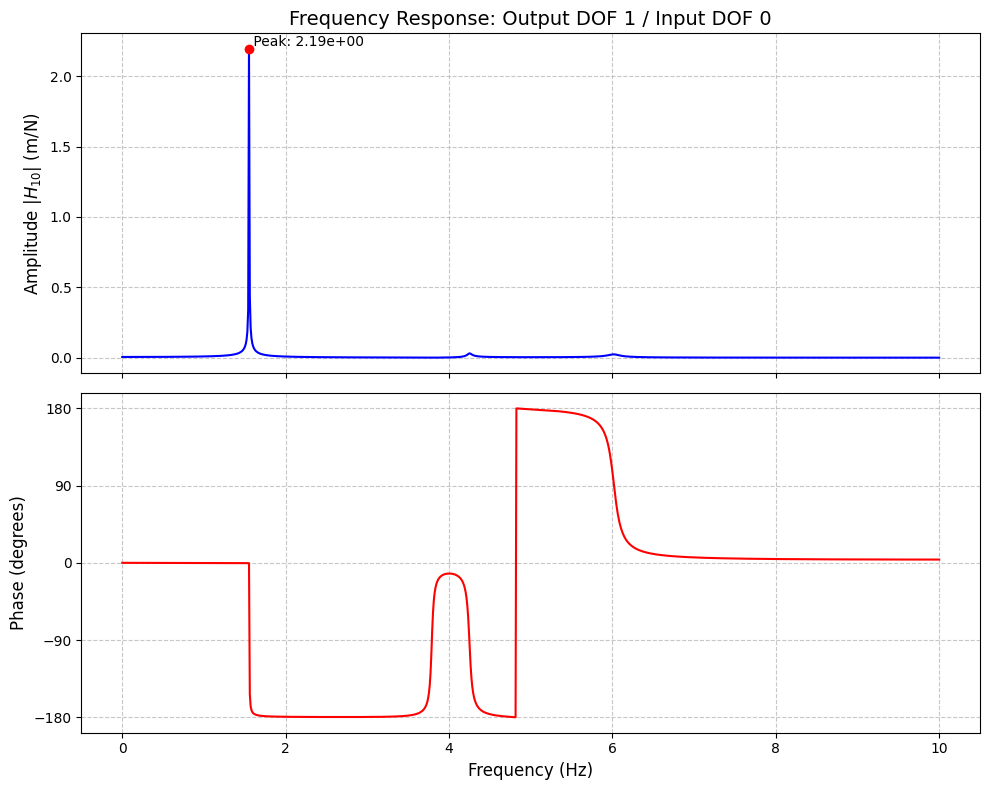

In [4]:
# 以一个典型的三自由度（3-DOF）系统为例：三个质量块 m, 之间用 k 和 c 连接
m1, m2, m3 = 0.5, 0.7, 0.3
k1, k2, k3 = 200, 300, 170 
c1, c2, c3 = 0.1, 0.2, 0.08  # 阻尼项

# 1. 质量矩阵 M
M = np.array([
    [m1, 0,  0],
    [0,  m2, 0],
    [0,  0,  m3]
])

# 2. 刚度矩阵 K (根据你的 EOM 推导填写)
K = np.array([
    [k1+k2, -k2,    0],
    [-k2,    k2+k3, -k3],
    [0,     -k3,    k3]
])

# 3. 阻尼矩阵 C (如果没有阻尼，设为全 0 矩阵)
C = np.array([
    [c1+c2, -c2,    0],
    [-c2,    c2+c3, -c3],
    [0,     -c3,    c3]
])

# 2. 调用通用函数
# 参数: (M, C, K, 输出DOF索引, 输入DOF索引, 频率起始Hz, 频率终止Hz)
# 注意: Python索引从0开始 (DOF1 -> 0, DOF2 -> 1)
modes_m, modes_u, resp = analyze_mdof_system(
    M, C, K, 
    i_dof=1,  # Output: 测量第二个质量的位移
    j_dof=0,  # Input:  力加在第一个质量上
    f_start=0, 
    f_end=10
)